In [1]:
import numpy as np
import os
import sys
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = "D:\\HK1_3\\ML\\ML-LT"  
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print(os.getcwd())
print(sys.path[:3])


from src.recommend_model.regression import CatBoostRecommender
from src.planner import RouteOptimizer, HistoryAnalyzer, TimeAwareMultiDayPlanner


TYPE_RELATIONS = {
    "coffee shop": ["cafe", "tea shop", "bakery"],
    "restaurant": ["vegetarian", "bakery", "food", "restaurant"],
    "bar/pub": ["restaurant"],
    "natural": ["attraction", "entertainment", "park", "beach"],
    "attraction": ["natural", "cultural", "historical"],
    "cultural": ["attraction", "historical", "museum"],
    "historical": ["attraction", "cultural"],
    "hotel": ["villa", "resort", "homestay", "hostel", "apartment"],
    "shopping": ["entertainment", "market", "mall"],
    "entertainment": ["shopping", "natural"],
}

def calculate_similarity_score(user_type, poi_type):
    u = str(user_type).lower().strip()
    p = str(poi_type).lower().strip()

    if u == p: return 0.30
    if p in TYPE_RELATIONS.get(u, []): return 0.15
    return 0.0

d:\HK1_3\ML\ML-LT\notebook
['D:\\HK1_3\\ML\\ML-LT', 'd:\\HK1_3\\ML\\ML-LT\\notebook', 'c:\\Users\\vandi\\anaconda3\\python312.zip']


In [2]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = phi2 - phi1
    dlambda = np.radians(lon2 - lon1)

    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def evaluate_schedule(schedule, poi_df):
    total_dist = 0.0
    total_poi = 0
    lunch_cafe_count = 0
    valid_days = 0

    poi_df = poi_df.set_index("poi_id")

    for day in schedule:
        route = day['route']
        if len(route) < 2:
            continue

        valid_days += 1
        total_poi += len(route)

        for i in range(len(route) - 1):
            a, b = route[i]['poi_id'], route[i+1]['poi_id']
            if a not in poi_df.index or b not in poi_df.index:
                continue

            lat1, lon1 = poi_df.loc[a, ['latitude', 'longitude']]
            lat2, lon2 = poi_df.loc[b, ['latitude', 'longitude']]
            total_dist += haversine(lat1, lon1, lat2, lon2)

        for step in route:
            if step.get('type') in ['Lunch', 'Coffee']:
                lunch_cafe_count += 1

    return {
        "num_poi": total_poi,
        "total_distance_km": round(total_dist, 2),
        "avg_distance_per_day": round(total_dist / max(valid_days, 1), 2),
        "num_days": valid_days,
        "has_lunch_cafe": lunch_cafe_count > 0
    }

def compare_planners(
    random_planner,
    greedy_planner,
    timeaware_planner,
    user_profile,
    total_days,
    start_poi_id,
    poi_df
):
    results = []

    planners = {
        "Random": lambda: random_planner.plan_itinerary(user_profile, total_days, pois_per_day=5),
        "Greedy": lambda: greedy_planner.plan_itinerary(user_profile, total_days, start_poi_id, pois_per_day=5),
        "TimeAware": lambda: timeaware_planner.plan_itinerary(user_profile, total_days, start_poi_id, pois_per_day=5)
    }

    for name, run_fn in planners.items():
        schedule = run_fn()
        metrics = evaluate_schedule(schedule, poi_df)
        metrics["model"] = name
        results.append(metrics)

    return pd.DataFrame(results)


In [ ]:
import numpy as np
import pandas as pd
from math import radians, cos, sin, asin, sqrt

class BenchmarkEngine:
    def __init__(self, df_poi):
        # Tạo bản sao và chuẩn hóa index
        self.df_poi = df_poi.copy()
        if 'poi_id' in self.df_poi.columns:
            self.df_poi['poi_id'] = self.df_poi['poi_id'].astype(str)
            self.df_poi = self.df_poi.set_index('poi_id')

    def _haversine(self, lat1, lon1, lat2, lon2):
        """Hàm tính khoảng cách nội bộ"""
        lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
        dlon = lon2 - lon1 
        dlat = lat2 - lat1 
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * asin(sqrt(a)) 
        return c * 6371

    def _is_restaurant(self, poi_type):
        """
        Kiểm tra xem loại địa điểm có phải là nơi ăn uống không.
        Dựa trên từ khóa trong database.
        """
        t = str(poi_type).lower()
        return any(k in t for k in TYPE_RELATIONS["restaurant"])

    def calculate_metrics(self, schedule, user_profile):
        """Tính toán metrics cho một lịch trình"""
        if not schedule: return None

        total_dist = 0.0
        total_pois = 0
        meals_count = 0 # Đếm tổng số bữa ăn (Lunch + Dinner + Cafe) dựa trên type thực tế
        match_scores = []
        
        # Duyệt qua từng ngày
        for day in schedule:
            route = day['route']
            if not route: continue

            # Lọc các bước hợp lệ (có ID trong DB)
            valid_steps = [s for s in route if str(s['poi_id']) in self.df_poi.index]
            
            # 1. Tính tổng quãng đường
            for i in range(len(valid_steps) - 1):
                id1 = str(valid_steps[i]['poi_id'])
                id2 = str(valid_steps[i+1]['poi_id'])
                
                lat1 = self.df_poi.at[id1, 'latitude']
                lon1 = self.df_poi.at[id1, 'longitude']
                lat2 = self.df_poi.at[id2, 'latitude']
                lon2 = self.df_poi.at[id2, 'longitude']
                
                total_dist += self._haversine(lat1, lon1, lat2, lon2)

            # 2. Phân tích từng điểm đến
            for step in valid_steps:
                pid = str(step['poi_id'])
                
                # Lấy Type thực tế từ Database
                p_type = self.df_poi.at[pid, 'type']
                
                if self._is_restaurant(p_type):
                    # Nếu type thực tế là nhà hàng/cafe -> Tính là một bữa ăn
                    meals_count += 1
                else:
                    # Nếu KHÔNG phải nhà hàng -> Coi là điểm tham quan (Visit)
                    total_pois += 1
                    
                    # Tính điểm khớp sở thích (chỉ tính cho điểm tham quan)
                    # print(f"[DEBUG] Visit: {pid} ({p_type}) - User: {user_profile['user_type']}")
                    score = calculate_similarity_score(user_profile['user_type'], p_type)
                    match_scores.append(score)

        avg_match = np.mean(match_scores) if match_scores else 0
        
        # Efficiency: Số POI tham quan (không tính ăn) trên mỗi 10km
        efficiency = (total_pois / total_dist * 10) if total_dist > 0 else 0

        return {
            "Total Distance (km)": round(total_dist, 2),
            "Avg Match Score": round(avg_match, 2),
            "Total Visits": total_pois,          # Chỉ đếm các điểm chơi
            "Meals Scheduled": meals_count,      # Số lượng quán ăn/cafe ghé qua
            "Efficiency (Visit/10km)": round(efficiency, 2)
        }

    def run_comparison(self, planners_dict, user_profile, total_days, start_id, pois_per_day):
        results = []
        print(f"\n>>> Running Benchmark for User Type: '{user_profile['user_type']}'...")
        
        for name, planner in planners_dict.items():
            try:
                schedule = planner.plan_itinerary(user_profile, total_days, start_id, pois_per_day)
                metrics = self.calculate_metrics(schedule, user_profile)
                
                if metrics:
                    metrics['Algorithm'] = name
                    results.append(metrics)
                    print(f"   {name}: Finished.")
                else:
                    print(f"   {name}: No schedule generated.")
            except Exception as e:
                print(f"   {name}: Error - {e}")

        return pd.DataFrame(results)

In [4]:
class RandomPlanner:
    def __init__(self, recommender, poi_df):
        self.recommender = recommender
        self.poi_df = poi_df.copy()

    def plan_itinerary(self, user_profile, total_days, start_poi_id, pois_per_day):
        all_scored = self.recommender.recommend(
            self.poi_df.reset_index(drop=True),
            user_profile['user_city'],
            '',
            user_profile['user_price'],
            top_k=100
        )

        if all_scored.empty:
            return []

        poi_ids = all_scored['poi_id'].tolist()
        random.shuffle(poi_ids)

        needed = total_days * pois_per_day
        poi_ids = poi_ids[:needed]

        schedule = []
        chunks = np.array_split(poi_ids, total_days)

        for d, day_pois in enumerate(chunks):
            route = []

            # ---- START HOTEL ----
            route.append({
                "order": 0,
                "poi_id": start_poi_id,
                "type": "Start"
            })

            # ---- VISITS ----
            for i, pid in enumerate(day_pois):
                route.append({
                    "order": i + 1,
                    "poi_id": pid,
                    "type": "Visit"
                })

            # ---- RETURN HOTEL ----
            route.append({
                "order": len(route),
                "poi_id": start_poi_id,
                "type": "Return Hotel"
            })

            schedule.append({
                "day": d + 1,
                "route": route
            })

        return schedule

class GreedyPlanner:
    def __init__(self, recommender, poi_df):
        self.recommender = recommender
        self.poi_df = poi_df.copy().set_index('poi_id')

    def _dist(self, id1, id2):
        try:
            lat1, lon1 = self.poi_df.loc[id1, ['latitude', 'longitude']]
            lat2, lon2 = self.poi_df.loc[id2, ['latitude', 'longitude']]
            return np.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)
        except:
            return 1e9

    def plan_itinerary(self, user_profile, total_days, start_poi_id, pois_per_day):
        all_scored = self.recommender.recommend(
            self.poi_df.reset_index(),
            user_profile['user_city'],
            '',
            user_profile['user_price'],
            top_k=100
        )

        if all_scored.empty:
            return []

        remaining = set(all_scored['poi_id'].tolist())
        if start_poi_id in remaining:
            remaining.remove(start_poi_id)

        schedule = []

        for d in range(total_days):
            day_route = []
            current = start_poi_id 

            # ---- START HOTEL ----
            day_route.append({
                "order": 0,
                "poi_id": start_poi_id,
                "type": "Start"
            })

            # ---- GREEDY VISITS ----
            for i in range(pois_per_day):
                if not remaining:
                    break

                next_poi = min(remaining, key=lambda x: self._dist(current, x))
                remaining.remove(next_poi)

                day_route.append({
                    "order": i + 1,
                    "poi_id": next_poi,
                    "type": "Visit"
                })

                current = next_poi

            # ---- RETURN HOTEL ----
            day_route.append({
                "order": len(day_route),
                "poi_id": start_poi_id,
                "type": "Return Hotel"
            })

            schedule.append({
                "day": d + 1,
                "route": day_route
            })

        return schedule


✓ [CatBoost] Model loaded.
History Patterns Learned: 2108 nodes.
✓ Điểm xuất phát: hotel01843

>>> Running Benchmark for User Type: 'natural'...
   Random: Finished.
   Greedy: Finished.
   Time-Aware (Ours): Finished.

=== BẢNG KẾT QUẢ ===
                   Total Distance (km)  Avg Match Score  Total Visits  \
Algorithm                                                               
Random                           77.45             0.02            18   
Greedy                           32.79             0.03            18   
Time-Aware (Ours)                78.80             0.15            18   

                   Meals Scheduled  Efficiency (Visit/10km)  
Algorithm                                                    
Random                           0                     2.32  
Greedy                           0                     5.49  
Time-Aware (Ours)                6                     2.28  


C:\Users\vandi\AppData\Local\Temp\ipykernel_19204\2703562373.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Algorithm', y='Total Distance (km)', ax=axes[0], palette='Reds')
C:\Users\vandi\AppData\Local\Temp\ipykernel_19204\2703562373.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Algorithm', y='Avg Match Score', ax=axes[1], palette='Greens')
C:\Users\vandi\AppData\Local\Temp\ipykernel_19204\2703562373.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Algorithm', y='Me

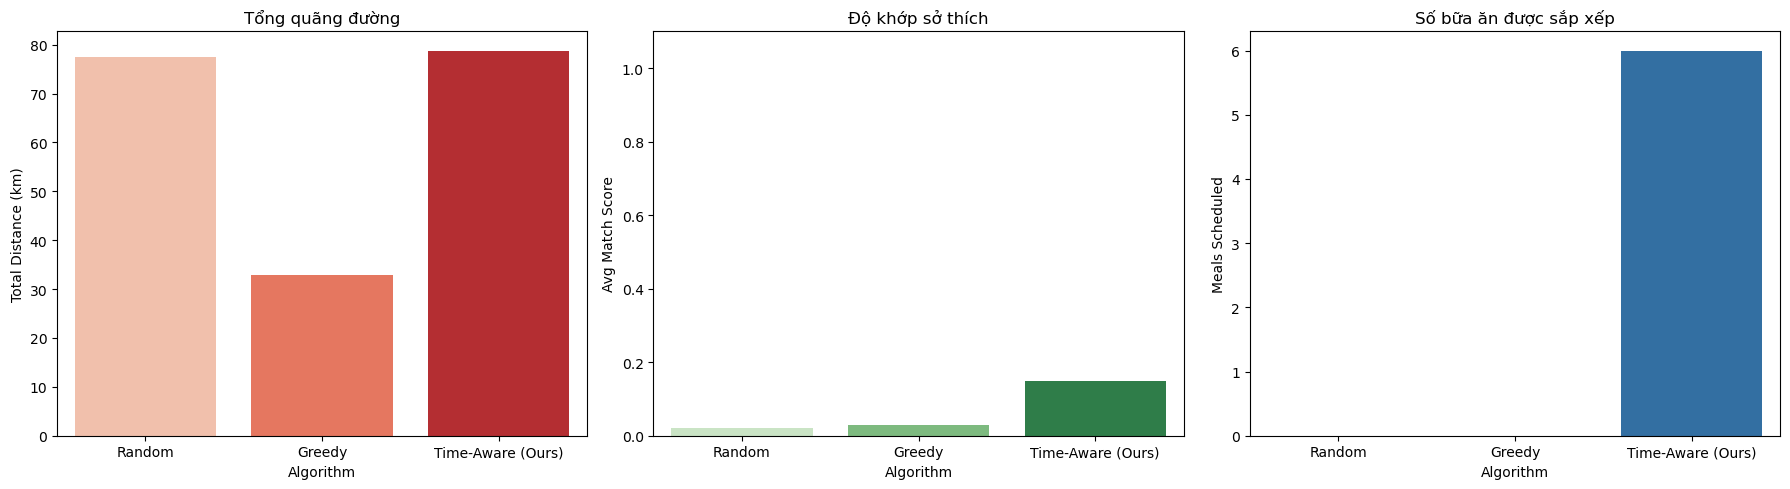

In [ ]:

PATH = {
    "poi": '../data/POI.csv',
    "dist": '../data/distance_km.csv',
    "dur": '../data/duration_min.csv',
    "history": '../data/itinerary_history.csv',
    "model_rec": '../models/catboost_rec_final.pkl'
}

df_poi = pd.read_csv(PATH['poi'])

rec_engine = CatBoostRecommender()
rec_engine.load(PATH['model_rec'])

opt_engine = RouteOptimizer(PATH['dist'], PATH['dur'], PATH['poi'])
hist_engine = HistoryAnalyzer()
if os.path.exists(PATH["history"]): hist_engine.fit(PATH["history"])

planner = TimeAwareMultiDayPlanner(rec_engine, opt_engine, df_poi, hist_engine)

# Init Benchmark Engine
benchmark = BenchmarkEngine(pd.read_csv(PATH['poi']))

# Init Planners
# (Lưu ý: Đảm bảo class RandomPlanner và GreedyPlanner đã update logic 'Return Hotel' như các bài trước)
random_p = RandomPlanner(rec_engine, pd.read_csv(PATH['poi']))
greedy_p = GreedyPlanner(rec_engine, pd.read_csv(PATH['poi']))
ours_p = TimeAwareMultiDayPlanner(rec_engine, opt_engine, pd.read_csv(PATH['poi']), hist_engine)

planners = {
    "Random": random_p,
    "Greedy": greedy_p,
    "Time-Aware (Ours)": ours_p
}

# --- 2. CONFIG USER & START POINT ---
user_req = {
    "user_city": "ha noi", 
    "user_type": "natural",  # Thử đổi thành 'nature' hoặc 'food'
    "user_price": 1
}

# Tìm điểm xuất phát (Hotel)
city_key = user_req['user_city'].lower().strip()
city_data = df_poi[df_poi['city_norm'] == city_key]

if not city_data.empty:
    hotels = city_data[city_data['type'].str.contains('hotel', case=False)]
    start_id = hotels.iloc[0]['poi_id'] if not hotels.empty else city_data.iloc[0]['poi_id']
    print(f"Điểm xuất phát: {start_id}")
    
    # --- 3. RUN & VISUALIZE ---
    df_results = benchmark.run_comparison(
        planners, 
        user_req, 
        total_days=3, 
        start_id=start_id, 
        pois_per_day=4
    )
    
    print("\n=== BẢNG KẾT QUẢ ===")
    print(df_results.set_index('Algorithm'))
    
    # Vẽ biểu đồ
    if not df_results.empty:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Biểu đồ 1: Hiệu quả đường đi
        sns.barplot(data=df_results, x='Algorithm', y='Total Distance (km)', ax=axes[0], palette='Reds')
        axes[0].set_title('Tổng quãng đường')
        
        # Biểu đồ 2: Độ chính xác sở thích
        sns.barplot(data=df_results, x='Algorithm', y='Avg Match Score', ax=axes[1], palette='Greens')
        axes[1].set_title('Độ khớp sở thích')
        axes[1].set_ylim(0, 1.1)
        
        # Biểu đồ 3: Sự quan tâm đến sức khỏe (Bữa ăn)
        sns.barplot(data=df_results, x='Algorithm', y='Meals Scheduled', ax=axes[2], palette='Blues')
        axes[2].set_title('Số bữa ăn được sắp xếp')
        
        plt.tight_layout()
        plt.show()

else:
    print("Không tìm thấy dữ liệu thành phố.")